In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ffmpeg


In [9]:
def extract_frames_ffmpeg(video_path, output_dir, quality=2, start_number=0, fps=None, file_pattern='%05d.jpg'):
    """
    Uses ffmpeg-python to extract frames from a video and save as images.

    Args:
        video_path (str): Path to the input video.
        output_dir (str): Directory to save the extracted frames.
        quality (int): Quality level for the output images (lower is better quality).
        start_number (int): Starting number for the output image filenames.
        fps (int/None): The framerate to extract frames at.
        file_pattern (str): Pattern for naming the output images (default: '%05d.jpg').
    
    Returns:
        None
    """
    if os.path.exists(output_dir):
        print(f'{output_dir} exists')
        return
    os.makedirs(output_dir, exist_ok=True)

    # Construct output file path pattern
    output_path = f'{output_dir}/{file_pattern}'

    # Use ffmpeg to extract frames
    stream = ffmpeg.input(video_path)
    if fps is not None:
        stream = stream.filter('fps', fps=fps, round='up')
    stream.output(
        output_path, 
        q=quality,  # Quality for the frames
        start_number=start_number  # Start number for frame file names
    ).run(quiet=True)

In [10]:
extract_frames_ffmpeg("35_cbr_mel_A1_04-06-2024-06042024031526-0000.avi", 'frames_very_large/', fps=5)

frames_very_large/ exists


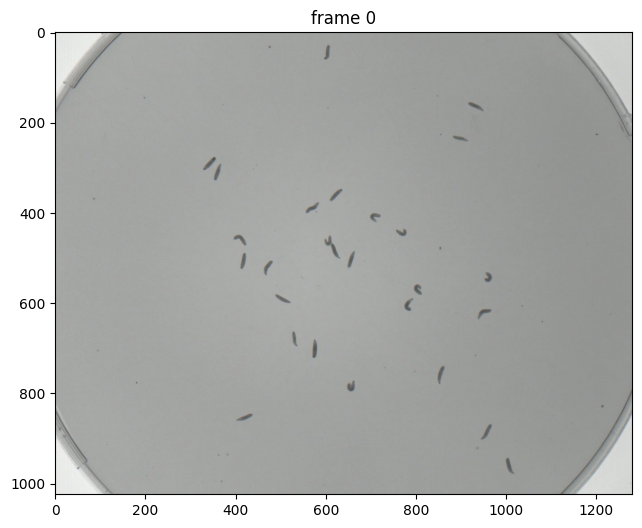

In [11]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "frames_very_large"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

# No need to detect circles !!!